# Machine Learning Algorithm1: Linear Regression

<a id='Index'></a>
# Exercise list:
* <a href='#Exercise-01'>Exercise-01</a>
* <a href='#Exercise-02'>Exercise-02</a>

In [1]:
%spark 16 32g

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/01 16:10:13 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in mesos/standalone/kubernetes and LOCAL_DIRS in YARN).


Welcome to
      ____              __
     / __/__  ___ _____/ /__
    _\ \/ _ \/ _ `/ __/  '_/
   /__ / .__/\_,_/_/ /_/\_\   version 3.4.2
      /_/

Using Python version 3.9.18 (main, Dec 15 2023 17:48:57)
Spark context Web UI available at None
Spark context available as 'sc' (master = local[*], app id = local-1759327813673).
SparkSession available as 'spark'.


In [2]:
%run handlers.ipynb

Pandas version:  2.1.4


# Read-in Manipulation DataFrames 

* Read in the DataFrames **produced in the DataManipulation** Notebook as .csv files.
* Pre-saved data are in the read-only directory **local_data_dir_ro**. Data you produced are in **local_data_dir**.
* The goal is to obtain the training and test DataFrames df_train and df_test.

In [3]:
df_names= ['df_train'+suffix_s_w+'.csv', \
           'df_test'+suffix_s_w+'.csv']

path_lustre = []
for filename in df_names:
    path_lustre.append(os.path.join(local_data_dir_ro, filename))

print("Reading in all DataFrames from manipulation in... ")
start_time = time.time()

df_train = spark.read.option('header', True).option('inferSchema', True).csv(os.path.join(LustrePrefix,path_lustre[0])).cache()
df_test = spark.read.option('header', True).option('inferSchema', True)\
    .csv(os.path.join(LustrePrefix,path_lustre[1])).cache()

print("--- %.0f min. %.2f sec.---" % (np.floor_divide(time.time() - start_time, 60),
    np.remainder(time.time() - start_time, 60)))

Reading in all DataFrames from manipulation in... 


25/10/01 16:10:43 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


--- 0 min. 4.10 sec.---


In [4]:
# Have a look at the training DataFrame:
df_train.printSchema()
#print('Number of entries (rows) in df_train:', df_train.count())

root
 |-- MONAT: integer (nullable = true)
 |-- TAG: integer (nullable = true)
 |-- STUNDE_SOLL: integer (nullable = true)
 |-- MINUTE_RANGE: integer (nullable = true)
 |-- ZUGEREIGNIS_LINIE: integer (nullable = true)
 |-- SERVICE_START_ZEIT: integer (nullable = true)
 |-- ZUGEREIGNIS_ISTZEIT: integer (nullable = true)
 |-- ZUGEREIGNIS_TYP: integer (nullable = true)
 |-- ZUGEREIGNIS_SOLLZEIT: integer (nullable = true)
 |-- SERVICE_ID: long (nullable = true)
 |-- ZUGEREIGNIS_ZUGNUMMER: integer (nullable = true)
 |-- ZUGEREIGNIS_DS100: string (nullable = true)
 |-- MINUTE_SOLL: integer (nullable = true)
 |-- STUNDE_SER: integer (nullable = true)
 |-- MINUTE_SER: integer (nullable = true)
 |-- WOCHENTAG_SER: string (nullable = true)
 |-- WOCHENTAG_SOLL: string (nullable = true)
 |-- VERSPAETUNG: integer (nullable = true)
 |-- LAUFSZEIT: integer (nullable = true)
 |-- Datum: timestamp (nullable = true)
 |-- Mittelwerte_Temperatur: double (nullable = true)
 |-- Mittelwerte_Rel_Feuchte: doub

# Prediction of the continuous delay with Linear Regression 

## Combinations of features
* The lists "columns to index" (col_to_inx) and "columns index" (col_inx) contain the same features (respectively without or with the "_index" suffix).
* **A different order of the two lists** does **not** have an impact on the LR algorithm.


* These feature combinations are ordered **from best to worst** prediction result (columns_index5, 4, 3, 2, 1), according to previous tests.

In [5]:
# Delay at station -1,-2 + Duration and additional features + Weather:
col_to_inx5 = [ 'ZUGEREIGNIS_DS100',  'STUNDE_SOLL',\
                    'LAUFSZEIT', 'prev0_VERSPAETUNG', 'prev1_prev0_VERSPAETUNG', 'Mittel_NO', 'Mittel_WG', 'ZUGEREIGNIS_TYP']
col_inx5 = [ 'prev0_VERSPAETUNG_INDEX','prev1_prev0_VERSPAETUNG_INDEX', 'ZUGEREIGNIS_DS100_INDEX', 'ZUGEREIGNIS_TYP_INDEX', \
                 'STUNDE_SOLL_INDEX', 'LAUFSZEIT_INDEX','Mittel_WG_INDEX', 'Mittel_NO_INDEX']

# Only delay at station -1,-2:
col_to_inx4 = ['prev0_VERSPAETUNG', 'prev1_prev0_VERSPAETUNG']
col_inx4 = ['prev0_VERSPAETUNG_INDEX', 'prev1_prev0_VERSPAETUNG_INDEX']

# Only delay at station -1:
col_to_inx3 = ['prev0_VERSPAETUNG']
col_inx3 = ['prev0_VERSPAETUNG_INDEX']

# Basic information of the original dataset (without additional features) + Weather information:
col_to_inx2 = ['ZUGEREIGNIS_ZUGNUMMER', 'ZUGEREIGNIS_DS100', 'SERVICE_START_ZEIT', \
                  'Mittelwerte_Temperatur', 'Mittel_WG', 'ZUGEREIGNIS_SOLLZEIT',\
                    'Summe_Niederschalg', 'Mittel_NO', 'Mittel_NO2', 'Mittel_O3', 'Mittel_PM10']
col_inx2 = ['ZUGEREIGNIS_ZUGNUMMER_INDEX', 'ZUGEREIGNIS_DS100_INDEX', 'SERVICE_START_ZEIT_INDEX', \
                 'Mittelwerte_Temperatur_INDEX', 'ZUGEREIGNIS_SOLLZEIT_INDEX',\
                  'Mittel_WG_INDEX',  'Summe_Niederschalg_INDEX', 'Mittel_NO_INDEX', \
                    'Mittel_NO2_INDEX', 'Mittel_O3_INDEX', 'Mittel_PM10_INDEX']

# Basic information of the original dataset:
col_to_inx1 = ['ZUGEREIGNIS_ZUGNUMMER', 'ZUGEREIGNIS_DS100', 'SERVICE_START_ZEIT', \
                  'ZUGEREIGNIS_SOLLZEIT', 'SERVICE_ID']
col_inx1 = ['ZUGEREIGNIS_ZUGNUMMER_INDEX', 'ZUGEREIGNIS_DS100_INDEX', 'SERVICE_START_ZEIT_INDEX', \
                  'ZUGEREIGNIS_SOLLZEIT_INDEX', 'SERVICE_ID_INDEX']

col_to_inx_list = []
col_to_inx_list.append(col_to_inx1)
col_to_inx_list.append(col_to_inx2)
col_to_inx_list.append(col_to_inx3)
col_to_inx_list.append(col_to_inx4)
col_to_inx_list.append(col_to_inx5)

col_inx_list = []
col_inx_list.append(col_inx1)
col_inx_list.append(col_inx2)
col_inx_list.append(col_inx3)
col_inx_list.append(col_inx4)
col_inx_list.append(col_inx5)

# Only during the live course:
* ## Please stop here (introduction).
* ## Open the Notebook Handlers.ipynb at this point.

# Self-learning course:
* ## Open the Notebook Handlers.ipynb to be aware of the Linear Regression Pipeline.
* ## Proceed with this Notebook for the exercises. 

## Training of the model
* Run the Linear Regression ML-Pipelines.
* **Fit the model** for all defined combinations of feature columns.
* Output: **eva_X, model_X** = evaluator and model that will be applied to the test DataFrame for prediction.

## Important remark:
* **local_ml_dir_ro** = read-only directory (contains pre-saved models).
* **local_ml_dir**    = write-directory (where trained models are saved if training is executed).

# Only during the live course:
* ## Set to False (it might take some time).
  * It might also crash on Jupyter Notebook: We use pre-trained models instead.

# Self-learning course:
* ## Set to True. 

In [7]:
if (True):
    for i in (list(range(len(col_inx_list)))): # Loop over the feature combinations
        print("Running linreg pipeline " + str(i+1) + "...")
        start_time = time.time()
        
        eva_i, model_i  = MLPipeline_LR.linReg(df_train, col_to_inx_list[i], col_inx_list[i])
        
        path=os.path.join(local_ml_dir, 'linRegModel_featSet'+str(i+1)+suffix_s_w)
        print("Writing down model " + str(i+1) + "...")
        model_i.bestModel.write().overwrite().save(os.path.join(LustrePrefix,path))
        print("--- %.0f min. %.2f sec.---" % (np.floor_divide(time.time() - start_time, 60),
                                              np.remainder(time.time() - start_time, 60)))

Running linreg pipeline 1...


25/10/01 16:20:56 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/10/01 16:20:56 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/10/01 16:20:56 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/10/01 16:20:57 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/10/01 16:20:57 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/10/01 16:20:58 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/10/01 16:20:59 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/10/01 16:20:59 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/10/01 16:21:00 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/10/01 16:21:00 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/10/01 16:21:01 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/10/01 16:21:01 WARN DAGScheduler: Broadcasting larg

Writing down model 1...


25/10/01 16:23:07 WARN TaskSetManager: Stage 1129 contains a task of very large size (1468 KiB). The maximum recommended task size is 1000 KiB.


--- 2 min. 13.68 sec.---
Running linreg pipeline 2...


25/10/01 16:23:11 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/10/01 16:23:12 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/10/01 16:23:12 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/10/01 16:23:13 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/10/01 16:23:13 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/10/01 16:23:13 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/10/01 16:23:16 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/10/01 16:23:16 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/10/01 16:23:17 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/10/01 16:23:17 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/10/01 16:23:18 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/10/01 16:23:18 WARN DAGScheduler: Broadcasting larg

Writing down model 2...


25/10/01 16:26:17 WARN TaskSetManager: Stage 2761 contains a task of very large size (1468 KiB). The maximum recommended task size is 1000 KiB.


--- 3 min. 10.68 sec.---
Running linreg pipeline 3...
Writing down model 3...
--- 0 min. 36.80 sec.---
Running linreg pipeline 4...
Writing down model 4...
--- 0 min. 44.58 sec.---
Running linreg pipeline 5...
Writing down model 5...
--- 1 min. 37.56 sec.---


<a href='#Index'>Exercise Index</a>
<a id='Exercise-01'></a>

**EXERCISE 1**
* Define the **Evaluator** for our model with the function RegressionEvaluator().
* The target or label column is the delay (**"VERSPAETUNG"**).
* The prediction will be stored in a new column (**"prediction"**).
* The chosen Evaluator is the root mean squared error (**"rmse"**).

In [8]:
# Read-in and evaluate the model
modelEval=RegressionEvaluator(labelCol="VERSPAETUNG", predictionCol="prediction", metricName="rmse")

<a href='#Index'>Exercise Index</a>
<a id='Exercise-02'></a>

**EXERCISE 2**
* The fitted model has been either produced with training in the blocks above and saved, or previously stored. It can now be **loaded**.


* **Obtain model_1** as follows:
  * Use PipelineModel.load(...) to read-in the fitted model 'linRegModel_featSet**1**'.
* The RMSE on the test dataset is computed with the function linRegTest defined in the Handlers.
  * This function applies the model to the test DataFrame and evaluates the result.

* Also define the **labels** for the plot (next blocks), by adding the number of feature combination (depends on the loop iterator **i**).

# Only during the live course:
* ## Use "local_ml_dir_ro" (pretrained model)

# Self-learning course:
* ## Use "local_ml_dir" (your model)

Feature set 1


25/10/01 16:37:53 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB


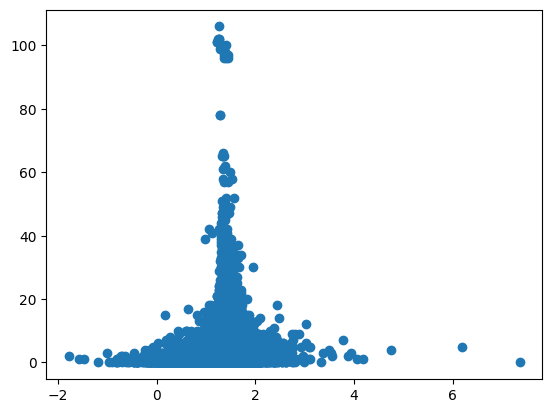

25/10/01 16:37:56 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB


Root Mean Squared Error (RMSE) on data = 2.62794
[2.6279388890002577]
--- Evaluated regression model 5  ---
--- 0 min. 4.75 sec.---


25/10/01 16:37:56 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB


In [14]:
rmse_list_test = []  # Collect the RMSE for each model on the test dataset
labels = []          # Labels for the barplot

start_time = time.time()

for i in (list(range(1))):
    print('Feature set', i+1)
    path=os.path.join(LustrePrefix,local_ml_dir, 'linRegModel_featSet'+str(i+1)+suffix_s_w)

    model_i       = PipelineModel.load(path)
    rmse_test     = MLPipeline_LR.linRegTest(df_test, modelEval, model_i)

    feat_num = str(len(col_inx_list[i]))
    labels.append('Features' + feat_num)
    rmse_list_test.append(rmse_test)

    print(rmse_list_test)
    print("--- Evaluated regression model " + feat_num + "  ---")

print("--- %.0f min. %.2f sec.---" % (np.floor_divide(time.time() - start_time, 60),
       	                	          np.remainder(time.time() - start_time, 60)))

* **If the block above is working**, we can loop over **all** feature combinations (model 1 to model 5):

Feature set 1


25/10/01 16:39:12 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB


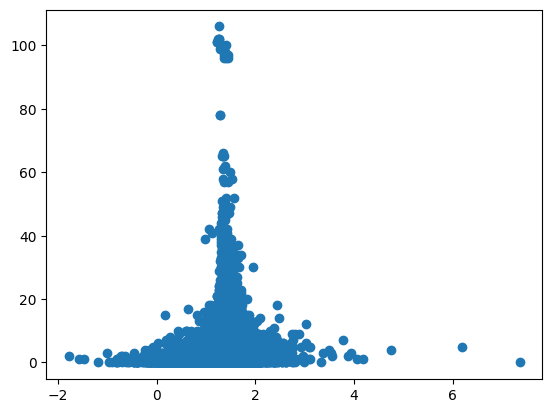

25/10/01 16:39:14 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/10/01 16:39:14 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB


Root Mean Squared Error (RMSE) on data = 2.62794
[2.6279388890002577]
--- Evaluated regression model 5  ---
Feature set 2


25/10/01 16:39:17 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB


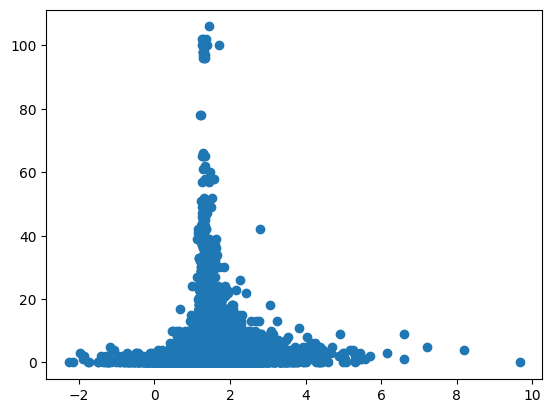

25/10/01 16:39:19 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/10/01 16:39:19 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB


Root Mean Squared Error (RMSE) on data = 2.62365
[2.6279388890002577, 2.623653891335487]
--- Evaluated regression model 11  ---
Feature set 3


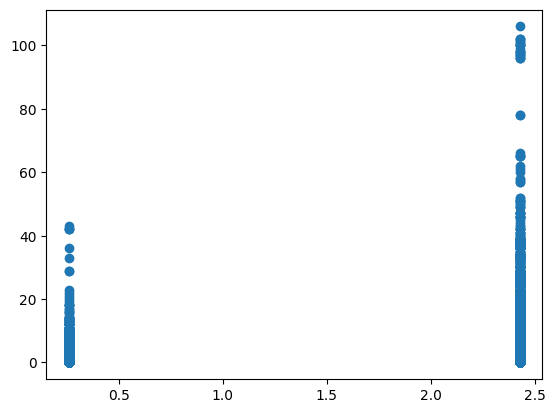

Root Mean Squared Error (RMSE) on data = 2.40096
[2.6279388890002577, 2.623653891335487, 2.400963920022049]
--- Evaluated regression model 1  ---
Feature set 4


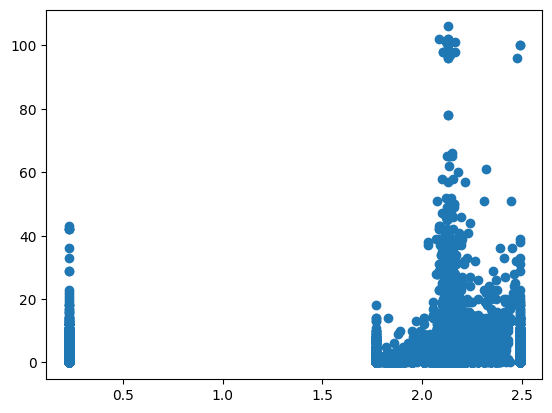

Root Mean Squared Error (RMSE) on data = 2.46138
[2.6279388890002577, 2.623653891335487, 2.400963920022049, 2.4613816139176747]
--- Evaluated regression model 2  ---
Feature set 5


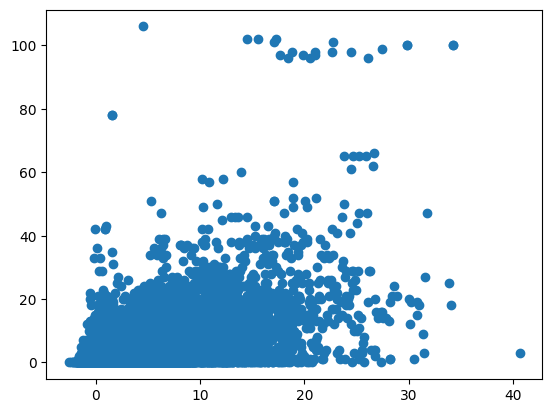

Root Mean Squared Error (RMSE) on data = 1.89168
[2.6279388890002577, 2.623653891335487, 2.400963920022049, 2.4613816139176747, 1.8916777259527426]
--- Evaluated regression model 8  ---
--- 0 min. 19.05 sec.---


In [15]:
rmse_list_test = []  # Collect the RMSE for each model on the test dataset
labels = []          # Labels for the barplot

start_time = time.time()

for i in (list(range(len(col_inx_list)))):
    print('Feature set', i+1)
    path=os.path.join(LustrePrefix,local_ml_dir, 'linRegModel_featSet'+str(i+1)+suffix_s_w)
    
    model_i    = PipelineModel.load(path)
    rmse_test  = MLPipeline_LR.linRegTest(df_test, modelEval, model_i)
    
    feat_num = str(len(col_inx_list[i]))
    labels.append('Features' + feat_num)
    rmse_list_test.append(rmse_test)

    print(rmse_list_test)
    print("--- Evaluated regression model " + feat_num + "  ---")

print("--- %.0f min. %.2f sec.---" % (np.floor_divide(time.time() - start_time, 60),
       	                	          np.remainder(time.time() - start_time, 60)))

# Barplot of the RMSE of the 5 combinations of feature columns
* Plot out here the RMSE after linear regression.
* See e.g. <a href=https://matplotlib.org/3.1.1/gallery/lines_bars_and_markers/barchart.html#sphx-glr-gallery-lines-bars-and-markers-barchart-py>this reference</a> for more details about plotting.

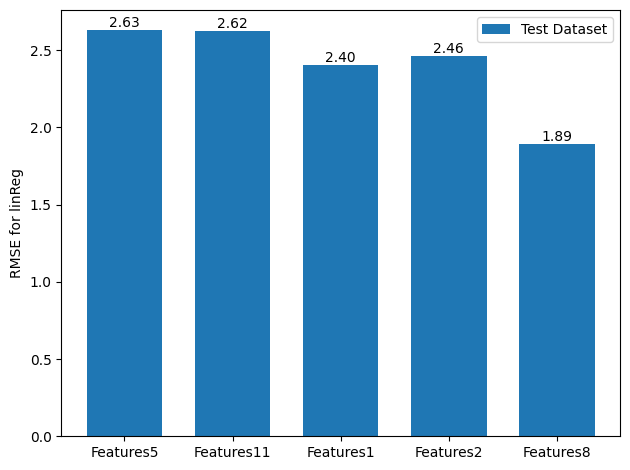

In [16]:
rmse_list_test_feat_var = rmse_list_test # RMSE for each model on the test dataset

x = np.arange(len(labels))  # the label locations
width = 0.35*2              # the width of the bars

fig, ax = plt.subplots()
rects = ax.bar(x, rmse_list_test_feat_var, width, label='Test Dataset')

# Add text for labels, title and custom x-axis tick labels.
ax.set_ylabel('RMSE for linReg')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.bar_label(rects,labels= ['%.2f' % e for e in rmse_list_test_feat_var])
ax.legend()

fig.tight_layout()

filename = 'Feature_testonly_rmse_bar'+ suffix_s_w
path = os.path.join(LustrePrefix,local_regression_plot_dir, filename)
plt.savefig(path)

## End of EX 2